In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Dropout
from keras.optimizers import SGD, Adam
from tensorflow.keras.optimizers import SGD
from keras import optimizers
from keras.callbacks import ReduceLROnPlateau, EarlyStopping


In [ ]:
!pip install kaggle


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vaishnavi2018","key":"c3628417483641f5e33aee2d8c4c667e"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d sachinpatel21/az-handwritten-alphabets-in-csv-format


Dataset URL: https://www.kaggle.com/datasets/sachinpatel21/az-handwritten-alphabets-in-csv-format
License(s): CC0-1.0
 66% 122M/185M [00:00<00:00, 1.28GB/s]
100% 185M/185M [00:00<00:00, 904MB/s] 


In [ ]:
!unzip az-handwritten-alphabets-in-csv-format.zip -d /content/A_Z


Archive:  az-handwritten-alphabets-in-csv-format.zip
  inflating: /content/A_Z/A_Z Handwritten Data.csv  
  inflating: /content/A_Z/A_Z Handwritten Data/A_Z Handwritten Data.csv  


In [ ]:
df = pd.read_csv('/content/A_Z/A_Z Handwritten Data.csv').astype('float32')
df

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372445,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
372446,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
372447,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
372448,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
x = df.drop('0', axis = 1)
y = df['0']

In [ ]:

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2)
x_train = np.reshape(x_train.values, (x_train.shape[0], 28, 28))
x_test = np.reshape(x_test.values, (x_test.shape[0], 28, 28))

print('Train Data Shape:', x_train.shape)
print('Test Data Shape:', x_test.shape)
print('Train Data Shape:', y_train.shape)
print('Test Data Shape:', y_test.shape)

Train Data Shape: (297960, 28, 28)
Test Data Shape: (74490, 28, 28)
Train Data Shape: (297960,)
Test Data Shape: (74490,)


In [ ]:
# to use in final prediction
word_dict = {
    0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X', 24:'Y',25:'Z'
}

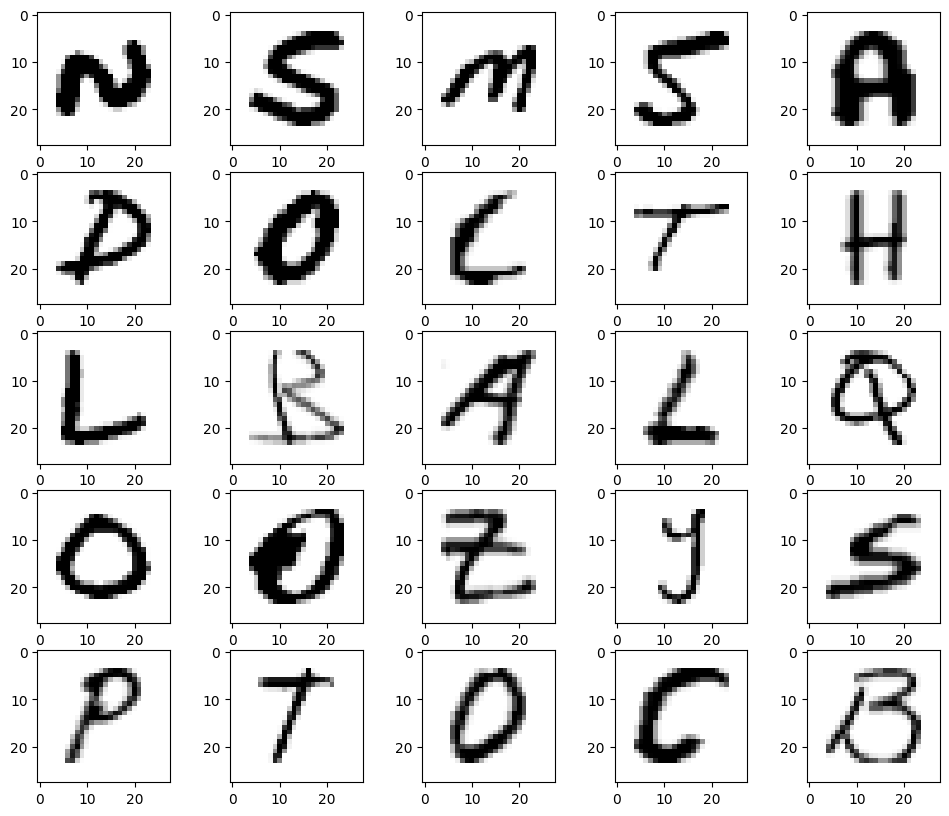

In [ ]:
# just to see random parts of dataset
plt.figure(figsize = (12,10))
row, colums = 5, 5
for i in range(25):
    plt.subplot(colums, row, i+1)
    plt.imshow(x_train[i].reshape([28,28]),interpolation='nearest', cmap='Greys')
plt.show()

In [ ]:
train_images = x_train / 255.0
test_images = x_test / 255.0

In [ ]:
train_images = train_images.reshape(train_images.shape[0], train_images.shape[1], train_images.shape[2], 1)
print("New shape of train data:", train_images.shape)

test_images = test_images.reshape(test_images.shape[0], test_images.shape[1], test_images.shape[2], 1)
print("New shape of test data:", test_images.shape)

#more like cnn we need (batch, height, width, channel) format

New shape of train data: (297960, 28, 28, 1)
New shape of test data: (74490, 28, 28, 1)


In [ ]:
import tensorflow as tf
number_of_classes = 26
ytrain = tf.keras.utils.to_categorical(y_train, number_of_classes)
ytest = tf.keras.utils.to_categorical(y_test, number_of_classes)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(train_images, ytrain, test_size=0.1, random_state=42)

In [ ]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))

model.add(Conv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same'))
model.add(MaxPool2D(pool_size=(2, 2), strides=2))
model.add(Dropout(0.2))
model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dense(26, activation="softmax"))

In [ ]:
model.compile(optimizer = Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

#introduced earky stopping if more then 5 values show no progress
early_stop = EarlyStopping(monitor='val_loss', min_delta=0, patience=5, verbose=0, mode='auto')

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=200, callbacks=[early_stop],  validation_data=(X_val, y_val))

Epoch 1/10
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8558 - loss: 0.5070 - val_accuracy: 0.9792 - val_loss: 0.0747
Epoch 2/10
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.9812 - loss: 0.0662 - val_accuracy: 0.9840 - val_loss: 0.0564
Epoch 3/10
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9860 - loss: 0.0488 - val_accuracy: 0.9862 - val_loss: 0.0481
Epoch 4/10
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9882 - loss: 0.0401 - val_accuracy: 0.9897 - val_loss: 0.0348
Epoch 5/10
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.9901 - loss: 0.0321 - val_accuracy: 0.9898 - val_loss: 0.0377
Epoch 6/10
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9919 - loss: 0.0259 - val_accuracy: 0.9913 - val_loss: 0.0323
Epoch 7/10
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9928 - loss: 0.0223 - val_accuracy: 0.9925 - val_loss: 0.0294
Epoch 8/10
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9935 - loss: 0

In [ ]:
from keras.models import load_model

model.save('my_modelcnn.h5')

In [ ]:
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 6, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 730,832 (2.79 MB)

 Trainable params: 243,610 (951.60 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 487,222 (1.86 MB)

None


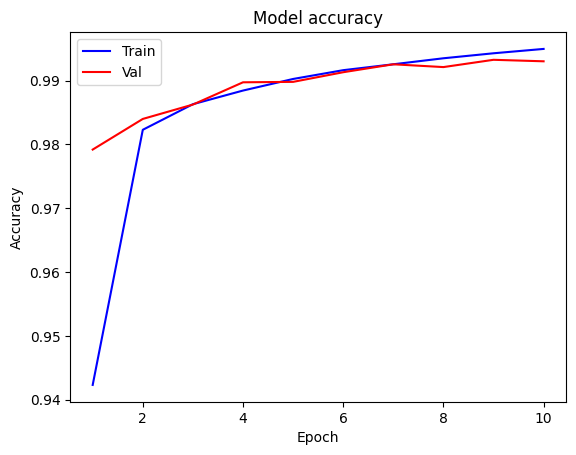

In [ ]:
def plotgraph(epochs, acc, val_acc):
    # Plot training & validation accuracy values
    plt.plot(epochs, acc, 'b')
    plt.plot(epochs, val_acc, 'r')
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Val'], loc='upper left')
    plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1,len(acc)+1)

plotgraph(epochs, acc, val_acc)

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/content/my_modelcnn.h5")


In [ ]:
from keras.models import load_model
model_path = '/content/my_modelcnn.h5'
loaded_model = load_model(model_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


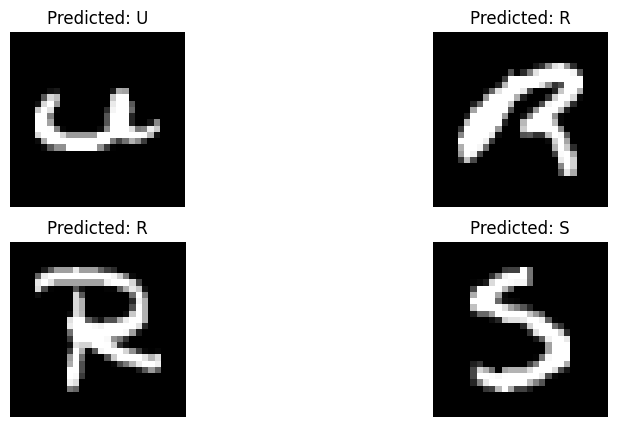

In [ ]:

# images 1000 to 1004 (or any range of 4)
selected_images = X_val[1112:1116] #(1-5,3000-3004)


# Make predictions for each image
predictions = loaded_model.predict(selected_images)

# Plot the images and predictions
plt.figure(figsize=(10, 5))
for i, (image, prediction) in enumerate(zip(selected_images, predictions), start=1):
    predicted_label = word_dict[np.argmax(prediction)]
    plt.subplot(2, 2, i)
    plt.imshow(image[:, :, 0], cmap='gray')
    plt.title(f'Predicted: {predicted_label}')
    plt.axis('off')

plt.show()